# Transport by DNA motors on DNA nanotube rails

**Model summary**

* A 100 µm square chamber holds 50 straight DNA nanotubes ("rails"), mean length 15 µm, at random positions and orientations. Each rail has its own polarity.
* Binding sites are spaced 14 nm apart. Each rail starts with a single **contiguous cluster of 15 ON sites (the seed, 210 nm)**. These seed sites are **permanent: restriction enzymes cannot switch them OFF**. They are drawn in bright orange.
* A transporter (400 nm ≈ 29 sites, 15 DNA motors + 15 polymerases) diffuses rapidly in solution and is invisible on screen. At rate `K_SEARCH` it encounters a random position on a rail and binds if any ON site lies within its footprint.
* Once bound it walks unidirectionally along the polarity at 10 nm/s, switching each newly covered leading site ON with probability `P_WRITE` (complementary-strand synthesis). It also detaches at the rail end.
* **Run length is proportional to the ON density f inside the footprint** (`RUN_SCALES_WITH_ON`): the per-site detachment probability is divided by f, so a densely ON rail holds its transporters longer. `RUN_LENGTH` is the run length at f = 1.
* Restriction enzymes are ubiquitous and switch ON sites back OFF at rate `K_OFF` [1/s], except for the seed cluster. Sites covered by a transporter are also protected (`PROTECT`).

→ A rail with more ON sites both captures transporters more easily and holds them longer, so it gains still more ON sites: a **positive feedback**.
Because ON density feeds into retention as well as capture, the feedback is superlinear and a threshold appears. Competing with enzymatic erasure, the rails split into an active and an inactive group.

**Visualization**: rails in gray, permanent seed sites in bright orange, written ON recognition sequences in red, transporters as thick blue bars (drawn only while bound).

In [ ]:
# ============================================================
#  Parameters (adjustable from the Colab form on the right)
# ============================================================
# --- Geometry ---
CHAMBER = 100.0        #@param {type:"number"}
N_RAILS = 50           #@param {type:"integer"}
RAIL_LEN_MEAN = 15.0   #@param {type:"number"}
RAIL_LEN_SD = 3.0      #@param {type:"number"}
SITE_SPACING = 0.014   #@param {type:"number"}
SEEDED_FRACTION = 1.0  #@param {type:"slider", min:0, max:1, step:0.05}
SEEDS_PER_RAIL = 15    #@param {type:"integer"}
# CHAMBER         : chamber edge length [um]
# N_RAILS         : number of rails
# RAIL_LEN_MEAN   : mean rail length [um]
# RAIL_LEN_SD     : standard deviation of rail length [um]
# SITE_SPACING    : binding-site spacing [um]  (14 nm)
# SEEDED_FRACTION : fraction of rails that carry a seed
# SEEDS_PER_RAIL  : number of seed sites per rail (permanent ON sites, immune to restriction enzymes)

# --- Transporter ---
N_TRANSPORTER = 40     #@param {type:"slider", min:1, max:400, step:1}
BODY_LEN = 0.400       #@param {type:"number"}
SPEED = 0.010          #@param {type:"number"}
RUN_LENGTH = 20.0      #@param {type:"number"}
K_SEARCH = 0.2         #@param {type:"number"}
# N_TRANSPORTER : number of transporters
# BODY_LEN      : transporter length [um]  (400 nm)
# SPEED         : walking speed [um/s]  (10 nm/s)
# RUN_LENGTH    : mean processive run length [um] at f = 1 (footprint fully ON)
# K_SEARCH      : rail-encounter attempt rate per transporter [1/s]

# --- Enzymatic ON/OFF competition ---
P_WRITE = 1.0          #@param {type:"slider", min:0, max:1, step:0.01}
K_OFF = 0.0008         #@param {type:"number"}
PROTECT = True         #@param {type:"boolean"}
# P_WRITE : probability that the polymerase writes ON per site advanced
# K_OFF   : ON -> OFF rate constant from restriction enzymes [1/s]
# PROTECT : whether sites covered by a transporter are shielded from cleavage

# --- Cooperativity (the two mechanisms that create bipolarization) ---
SEED_CLUSTERED = True  #@param {type:"boolean"}
SEED_AT_START = True   #@param {type:"boolean"}
RUN_SCALES_WITH_ON = True #@param {type:"boolean"}
ON_FLOOR = 0.02        #@param {type:"number"}
# SEED_CLUSTERED     : give the seed sites as one contiguous cluster (False = independently random positions)
# SEED_AT_START      : place the seed at the upstream end. With the seed further downstream a transporter
#                      can only reach part of the rail, so the reachable range (and the ON fraction) is set by seed position
# RUN_SCALES_WITH_ON : make the run length proportional to the ON density f inside the footprint
#                      (the detachment probability is divided by f; RUN_LENGTH then means the run length at f = 1)
# ON_FLOOR           : lower clip on f, capping the run length at RUN_LENGTH/ON_FLOOR

# --- Integration, sampling and rendering ---
DT = 0.5               #@param {type:"number"}
T_TOTAL = 16000.0      #@param {type:"number"}
SAMPLE_EVERY = 200.0   #@param {type:"number"}
SEED = 0               #@param {type:"integer"}
EXCLUSION = True       #@param {type:"boolean"}
RENDER_MODE = "density" #@param ["density", "sites"]
DRAW_OFFSET = 0.7      #@param {type:"number"}
# DT           : time step [s]
# T_TOTAL      : total simulated time [s]
# SAMPLE_EVERY : sampling interval [s]
# SEED         : random seed
# EXCLUSION    : whether transporters exclude each other on a rail
# RENDER_MODE  : how ON sites are drawn (density = binned occupancy, sites = individual dots)
# DRAW_OFFSET  : display-only perpendicular offset of transporters from the rail axis [um] (0 = on axis)

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams["figure.dpi"] = 100
plt.rcParams["animation.embed_limit"] = 300  # MB


# ============================================================
#  Rail generation
# ============================================================
def build_rails(rng):
    """Place straight rails at random, keeping each one entirely inside the chamber."""
    starts, dirs, lengths = [], [], []
    for _ in range(N_RAILS):
        for _try in range(20000):
            L = rng.normal(RAIL_LEN_MEAN, RAIL_LEN_SD)
            if L < 2.0 or L > CHAMBER:
                continue
            th = rng.uniform(0.0, 2.0 * np.pi)          # orientation = polarity (site 0 -> far end)
            u = np.array([np.cos(th), np.sin(th)])
            c = rng.uniform(0.0, CHAMBER, 2)
            p0, p1 = c - 0.5 * L * u, c + 0.5 * L * u
            if (p0 >= 0).all() and (p0 <= CHAMBER).all() and (p1 >= 0).all() and (p1 <= CHAMBER).all():
                starts.append(p0); dirs.append(u); lengths.append(L)
                break
        else:
            raise RuntimeError("Could not place a rail. Check CHAMBER and RAIL_LEN_* settings.")

    starts = np.array(starts)
    dirs = np.array(dirs)
    lengths = np.array(lengths)
    nsites = np.floor(lengths / SITE_SPACING).astype(int) + 1
    offsets = np.concatenate([[0], np.cumsum(nsites)])   # offsets into the global site array
    return dict(start=starts, dir=dirs, length=lengths, nsites=nsites,
                offset=offsets[:-1], total=int(offsets[-1]))


def site_xy(rails, rail_id, local_idx):
    """Coordinates [um] of local site local_idx on rail rail_id."""
    return rails["start"][rail_id] + rails["dir"][rail_id] * (local_idx * SITE_SPACING)


# ============================================================
#  Simulation core
# ============================================================
def simulate(verbose=True):
    rng = np.random.default_rng(SEED)
    rails = build_rails(rng)
    ns, off, total = rails["nsites"], rails["offset"], rails["total"]

    body = int(round(BODY_LEN / SITE_SPACING))           # sites covered by one transporter (400/14 ~ 29)
    p_step = SPEED * DT / SITE_SPACING                   # forward-step probability per time step
    assert p_step <= 0.6, "DT is too large; reduce it so that p_step <= 0.6."
    p_search = K_SEARCH * DT
    p_leave = SITE_SPACING / RUN_LENGTH                  # detachment probability per site advanced
    p_cut = K_OFF * DT

    # --- state variables ---
    on = np.zeros(total, dtype=bool)                     # ON/OFF state of every binding site
    occ = np.zeros(total, dtype=np.int16)                # occupancy by transporters
    perm = np.zeros(total, dtype=bool)                   # permanent ON sites (immune to restriction enzymes)

    # seed sites: SEEDS_PER_RAIL permanent ON sites per rail
    n_seeded = int(round(N_RAILS * SEEDED_FRACTION))
    seeded_rails = rng.permutation(N_RAILS)[:n_seeded]
    for j in seeded_rails:
        if SEED_CLUSTERED:
            a = 0 if SEED_AT_START else int(rng.integers(0, max(1, ns[j] - SEEDS_PER_RAIL)))
            on[off[j] + a: off[j] + a + SEEDS_PER_RAIL] = True   # contiguous seed cluster
            perm[off[j] + a: off[j] + a + SEEDS_PER_RAIL] = True
        else:
            for _ in range(SEEDS_PER_RAIL):
                g0 = off[j] + rng.integers(0, ns[j])
                on[g0] = True
                perm[g0] = True

    # transporters: -1 means free in solution (invisible)
    t_rail = np.full(N_TRANSPORTER, -1, dtype=np.int32)
    t_pos = np.zeros(N_TRANSPORTER, dtype=np.int32)      # trailing site of the footprint (local index)
    t_start = np.zeros(N_TRANSPORTER, dtype=np.int32)    # position where it bound (for recording run lengths)
    runs = []                                            # realized run lengths [um]

    # cumulative distribution for picking a rail (encounter rate scales with length)
    cdf = np.cumsum(ns / ns.sum())

    n_steps = int(round(T_TOTAL / DT))
    every = max(1, int(round(SAMPLE_EVERY / DT)))

    snaps = {"t": [], "on": [], "rail": [], "pos": []}

    def detach(i):
        g = off[t_rail[i]] + t_pos[i]
        occ[g:g + body] -= 1
        runs.append((t_pos[i] - t_start[i]) * SITE_SPACING)
        t_rail[i] = -1

    for s in range(n_steps + 1):
        # ---- sampling ----
        if s % every == 0:
            snaps["t"].append(s * DT)
            snaps["on"].append(on.copy())
            snaps["rail"].append(t_rail.copy())
            snaps["pos"].append(t_pos.copy())
        if s == n_steps:
            break

        # ---- transporter search, walking and detachment ----
        r = rng.random(N_TRANSPORTER)
        for i in range(N_TRANSPORTER):
            j = t_rail[i]
            if j < 0:
                # free in solution: try to encounter a random position on a rail
                if r[i] < p_search:
                    j = int(np.searchsorted(cdf, rng.random()))
                    if ns[j] <= body:
                        continue
                    pos = int(rng.integers(0, ns[j] - body + 1))
                    g = off[j] + pos
                    if EXCLUSION and occ[g:g + body].any():
                        continue
                    if not on[g:g + body].any():
                        continue          # no ON site under the footprint -> cannot bind
                    t_rail[i] = j
                    t_pos[i] = pos
                    t_start[i] = pos
                    occ[g:g + body] += 1
            else:
                # bound: advance one site along the rail polarity
                if r[i] < p_step:
                    pos = t_pos[i]
                    lead = pos + body                      # newly covered leading site
                    if lead >= ns[j]:
                        detach(i)                          # reached the end of the rail
                        continue
                    gl = off[j] + lead
                    if EXCLUSION and occ[gl] != 0:
                        continue                           # blocked from ahead -> stall
                    occ[off[j] + pos] -= 1
                    occ[gl] += 1
                    t_pos[i] = pos + 1
                    if rng.random() < P_WRITE:
                        on[gl] = True                      # switched ON by the polymerase
                    if RUN_SCALES_WITH_ON:
                        # higher ON density f inside the footprint -> longer run (this is the feedback)
                        f = on[gl - body + 1:gl + 1].sum() / body
                        pl = p_leave / max(f, ON_FLOOR)
                    else:
                        pl = p_leave
                    if rng.random() < pl:
                        detach(i)

        # ---- ON -> OFF by restriction enzymes ----
        idx = np.flatnonzero(on & ~perm)                 # permanent seed sites are never cut
        if idx.size:
            if PROTECT:
                idx = idx[occ[idx] == 0]
            if idx.size:
                on[idx[rng.random(idx.size) < p_cut]] = False

        if verbose and s % max(1, n_steps // 10) == 0:
            print(f"  t = {s*DT:7.0f} s   ON sites = {int(on.sum()):6d}   "
                  f"bound = {int((t_rail >= 0).sum()):4d}/{N_TRANSPORTER}")

    snaps["on"] = np.array(snaps["on"])
    snaps["rail"] = np.array(snaps["rail"])
    snaps["pos"] = np.array(snaps["pos"])
    snaps["t"] = np.array(snaps["t"])
    snaps["runs"] = np.array(runs, dtype=float)
    snaps["perm"] = perm
    return rails, snaps, body, seeded_rails

In [ ]:
print("Running simulation ...")
rails, snaps, BODY_SITES, SEEDED = simulate()
print(f"Done: total sites = {rails['total']}, snapshots = {len(snaps['t'])}, "
      f"transporter length = {BODY_SITES} sites")
if snaps["runs"].size:
    print(f"realized run length: mean {snaps['runs'].mean():.2f} um "
          f"(median {np.median(snaps['runs']):.2f} um, {snaps['runs'].size} runs)")
    print(f"  (shorter than RUN_LENGTH = {RUN_LENGTH} um because f < 1 and because runs are "
          f"truncated at the rail end; raising RUN_LENGTH saturates the mean at a few um)")

Running simulation ...
  t =       0 s   ON sites =    750   bound =    0/40
  t =    1600 s   ON sites =  11843   bound =   40/40
  t =    3200 s   ON sites =  12620   bound =   40/40
  t =    4800 s   ON sites =  13017   bound =   38/40
  t =    6400 s   ON sites =  13780   bound =   40/40
  t =    8000 s   ON sites =  14425   bound =   40/40
  t =    9600 s   ON sites =  15309   bound =   39/40
  t =   11200 s   ON sites =  14534   bound =   40/40
  t =   12800 s   ON sites =  14877   bound =   40/40
  t =   14400 s   ON sites =  15222   bound =   39/40
Done: total sites = 49333, snapshots = 81, transporter length = 29 sites
realized run length: mean 5.81 um (median 5.19 um, 1030 runs)
  (shorter than RUN_LENGTH = 20.0 um because f < 1 and because runs are truncated at the rail end; raising RUN_LENGTH saturates the mean at a few um)


In [ ]:
# ============================================================
#  Pre-computation for rendering
# ============================================================
SITES_PER_BIN = 40          # bin width for the density view (40 sites ~ 0.56 um)

def build_render_cache(rails):
    ns, off = rails["nsites"], rails["offset"]
    rail_segs = np.zeros((N_RAILS, 2, 2))
    bin_segs, bin_start, bin_size = [], [], []
    for j in range(N_RAILS):
        p0 = site_xy(rails, j, 0)
        p1 = site_xy(rails, j, ns[j] - 1)
        rail_segs[j] = [p0, p1]
        nb = max(4, ns[j] // SITES_PER_BIN)
        edges = np.linspace(0, ns[j], nb + 1).astype(int)
        for a, b in zip(edges[:-1], edges[1:]):
            if b <= a:
                continue
            bin_segs.append([site_xy(rails, j, a), site_xy(rails, j, max(a, b - 1))])
            bin_start.append(off[j] + a)
            bin_size.append(b - a)
    return (rail_segs, np.array(bin_segs), np.array(bin_start), np.array(bin_size, dtype=float))


RAIL_SEGS, BIN_SEGS, BIN_START, BIN_SIZE = build_render_cache(rails)


def build_perm_segs(rails, perm):
    """Extract the contiguous permanent-ON regions (seed clusters) as line segments."""
    p = np.concatenate([[False], perm, [False]]).astype(np.int8)
    d = np.diff(p)
    starts, ends = np.flatnonzero(d == 1), np.flatnonzero(d == -1)   # ends are exclusive
    segs = []
    for a, b in zip(starts, ends):
        j = int(np.searchsorted(rails["offset"], a, side="right") - 1)
        la, lb = a - rails["offset"][j], b - 1 - rails["offset"][j]
        segs.append([site_xy(rails, j, la), site_xy(rails, j, lb)])
    return np.array(segs) if segs else np.zeros((0, 2, 2))


PERM_SEGS = build_perm_segs(rails, snaps["perm"])


def on_density(on_snap):
    """ON fraction (0-1) within each bin."""
    return np.add.reduceat(on_snap.astype(np.int32), BIN_START) / BIN_SIZE


def transporter_segs(rail_snap, pos_snap):
    m = rail_snap >= 0
    if not m.any():
        return np.zeros((0, 2, 2))
    j, p = rail_snap[m], pos_snap[m]
    u = rails["dir"][j]
    n = np.stack([-u[:, 1], u[:, 0]], axis=1) * DRAW_OFFSET   # display-only perpendicular offset
    a = rails["start"][j] + u * (p[:, None] * SITE_SPACING) + n
    b = rails["start"][j] + u * ((p + BODY_SITES)[:, None] * SITE_SPACING) + n
    return np.stack([a, b], axis=1)


def draw_frame(ax, k, show_time=True):
    ax.set_xlim(-2, CHAMBER + 2); ax.set_ylim(-2, CHAMBER + 2)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.add_collection(LineCollection([[[0, 0], [CHAMBER, 0]], [[CHAMBER, 0], [CHAMBER, CHAMBER]],
                                      [[CHAMBER, CHAMBER], [0, CHAMBER]], [[0, CHAMBER], [0, 0]]],
                                     colors="k", linewidths=0.8))
    ax.add_collection(LineCollection(RAIL_SEGS, colors="0.72", linewidths=1.2))

    if RENDER_MODE == "density":
        d = on_density(snaps["on"][k])
        cols = np.zeros((len(d), 4)); cols[:, 0] = 1.0
        cols[:, 3] = np.clip(d, 0, 1)
        ax.add_collection(LineCollection(BIN_SEGS, colors=cols, linewidths=3.0))
    else:
        gi = np.flatnonzero(snaps["on"][k])
        if gi.size:
            j = np.searchsorted(rails["offset"], gi, side="right") - 1
            loc = gi - rails["offset"][j]
            xy = rails["start"][j] + rails["dir"][j] * (loc[:, None] * SITE_SPACING)
            ax.plot(xy[:, 0], xy[:, 1], ".", color="red", ms=1.5, alpha=0.75)

    # permanent seed sites in bright orange, drawn in front of the ordinary ON sites
    if len(PERM_SEGS):
        ax.add_collection(LineCollection(PERM_SEGS, colors="#ffb300", linewidths=4.2, zorder=3))

    segs = transporter_segs(snaps["rail"][k], snaps["pos"][k])
    ax.add_collection(LineCollection(segs, colors="#1155ee", linewidths=3.4, zorder=4))
    if show_time:
        ax.set_title(f"t = {snaps['t'][k]:.0f} s   |   ON = {int(snaps['on'][k].sum())}   "
                     f"|   bound = {int((snaps['rail'][k] >= 0).sum())}", fontsize=9)

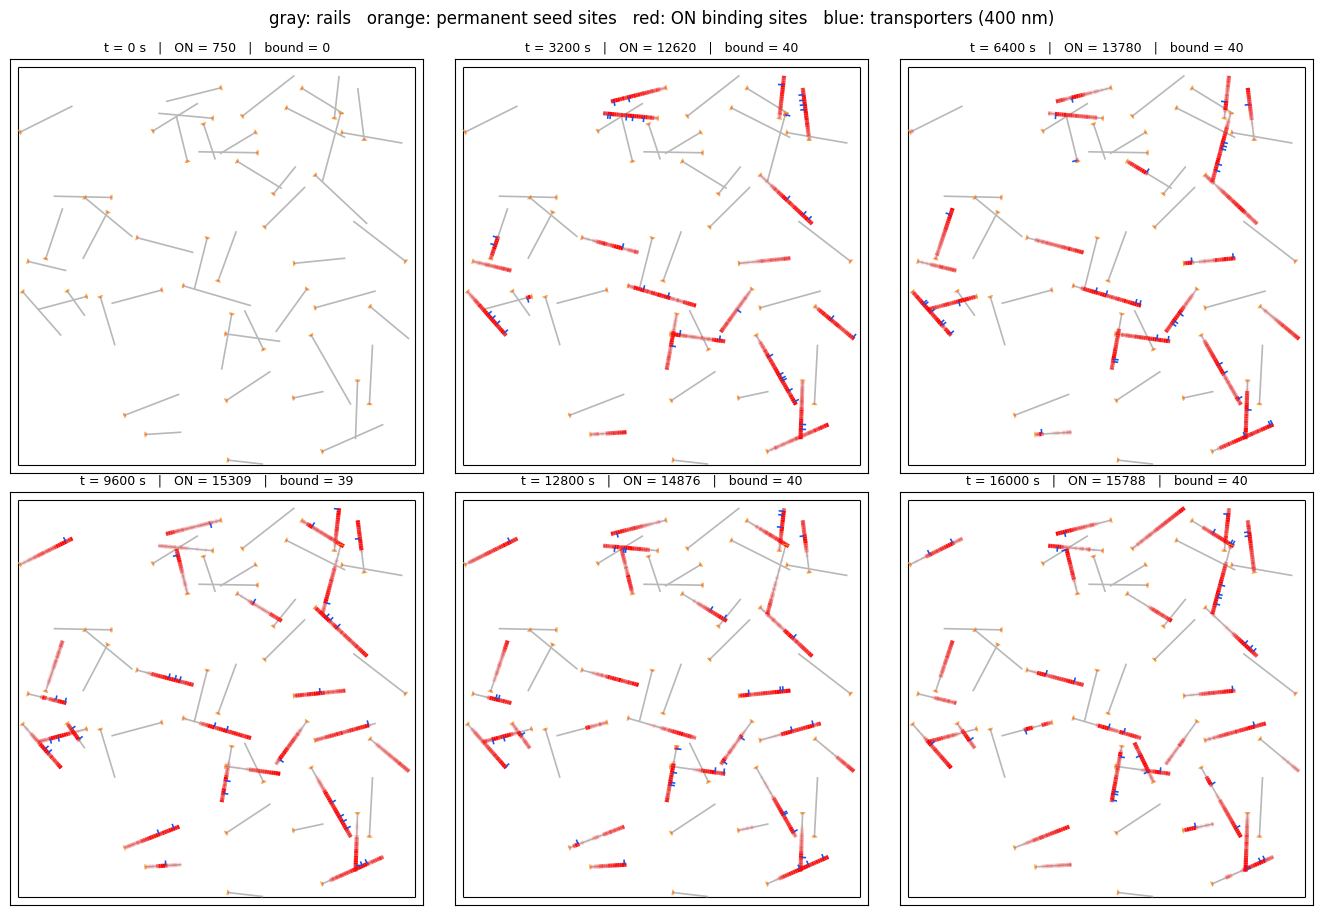

In [ ]:
# ============================================================
#  Static snapshots
# ============================================================
ks = np.linspace(0, len(snaps["t"]) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.2))
for ax, k in zip(axes.ravel(), ks):
    draw_frame(ax, k)
fig.suptitle("gray: rails   orange: permanent seed sites   red: ON binding sites   "
             "blue: transporters (400 nm)", y=0.99)
fig.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  Animation (played inline in Colab)
# ============================================================
fig, ax = plt.subplots(figsize=(6.4, 6.4))

def _update(k):
    ax.clear()
    draw_frame(ax, k)
    return []

anim = FuncAnimation(fig, _update, frames=len(snaps["t"]), interval=120, blit=False)
plt.close(fig)
display(HTML(anim.to_jshtml()))

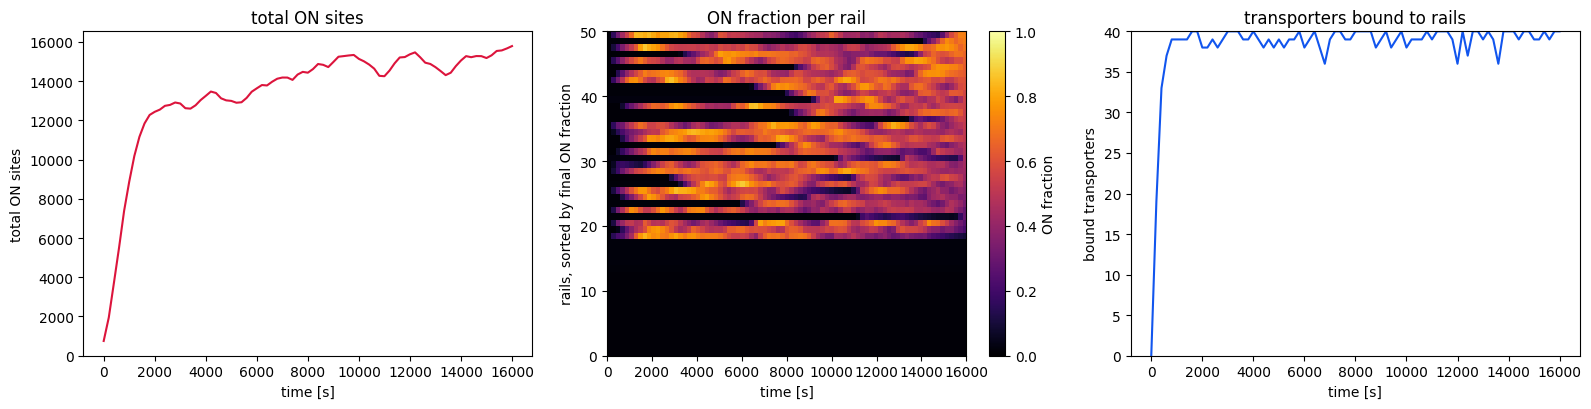

ON fraction of each rail at the final time point (descending):
  rail 28  ON =  71.5 %  (  685/958)
  rail  7  ON =  71.2 %  (  571/802)
  rail  5  ON =  69.5 %  (  721/1038)
  rail 46  ON =  66.0 %  (  858/1300)
  rail 23  ON =  64.5 %  (  689/1069)
  rail 25  ON =  63.4 %  (  730/1151)
  rail 49  ON =  62.7 %  (  672/1071)
  rail 16  ON =  60.0 %  (  471/785)
  rail 22  ON =  59.1 %  (  501/848)
  rail 39  ON =  56.6 %  (  511/903)
  rail 24  ON =  55.0 %  (  311/565)
  rail 27  ON =  54.6 %  (  584/1069)
  rail 10  ON =  53.2 %  (  570/1071)
  rail 12  ON =  53.0 %  (  640/1208)
  rail 18  ON =  51.8 %  (  491/947)
  rail  9  ON =  51.4 %  (  749/1458)
  rail 17  ON =  50.9 %  (  528/1037)
  rail 40  ON =  47.8 %  (  511/1070)
  rail 13  ON =  47.2 %  (  607/1287)
  rail  1  ON =  45.1 %  (  259/574)
  rail 19  ON =  44.1 %  (  538/1221)
  rail 29  ON =  42.9 %  (  558/1301)
  rail 11  ON =  41.2 %  (  403/978)
  rail 48  ON =  38.5 %  (  355/921)
  rail 45  ON =  37.0 %  (  371/100

In [ ]:
# ============================================================
#  Quantitative analysis of the time evolution
# ============================================================
onarr = snaps["on"]
t = snaps["t"]
per_rail = np.stack([np.add.reduceat(o.astype(np.int32), rails["offset"]) for o in onarr])  # (T, N_RAILS)
frac = per_rail / rails["nsites"][None, :]
bound = (snaps["rail"] >= 0).sum(axis=1)

order = np.argsort(frac[-1])          # sort rails by their final ON fraction

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))

axs[0].plot(t, onarr.sum(axis=1), color="crimson")
axs[0].set_xlabel("time [s]"); axs[0].set_ylabel("total ON sites"); axs[0].set_title("total ON sites")

im = axs[1].imshow(frac[:, order].T, aspect="auto", origin="lower", cmap="inferno",
                   extent=[t[0], t[-1], 0, N_RAILS], vmin=0, vmax=1)
axs[1].set_xlabel("time [s]"); axs[1].set_ylabel("rails, sorted by final ON fraction")
axs[1].set_title("ON fraction per rail")
fig.colorbar(im, ax=axs[1], label="ON fraction")

axs[2].plot(t, bound, color="#1155ee")
axs[2].set_xlabel("time [s]"); axs[2].set_ylabel("bound transporters")
axs[2].set_ylim(0, N_TRANSPORTER); axs[2].set_title("transporters bound to rails")

fig.tight_layout(); plt.show()

print("ON fraction of each rail at the final time point (descending):")
for j in order[::-1]:
    print(f"  rail {j:2d}  ON = {frac[-1, j]*100:5.1f} %  ({per_rail[-1, j]:5d}/{rails['nsites'][j]})")

B*      =   1.1  transporters required to sustain one fully ON rail
supply  =   0.8  transporters available per rail on average
N_ON_max=  36.2  rails that can be held fully ON at once


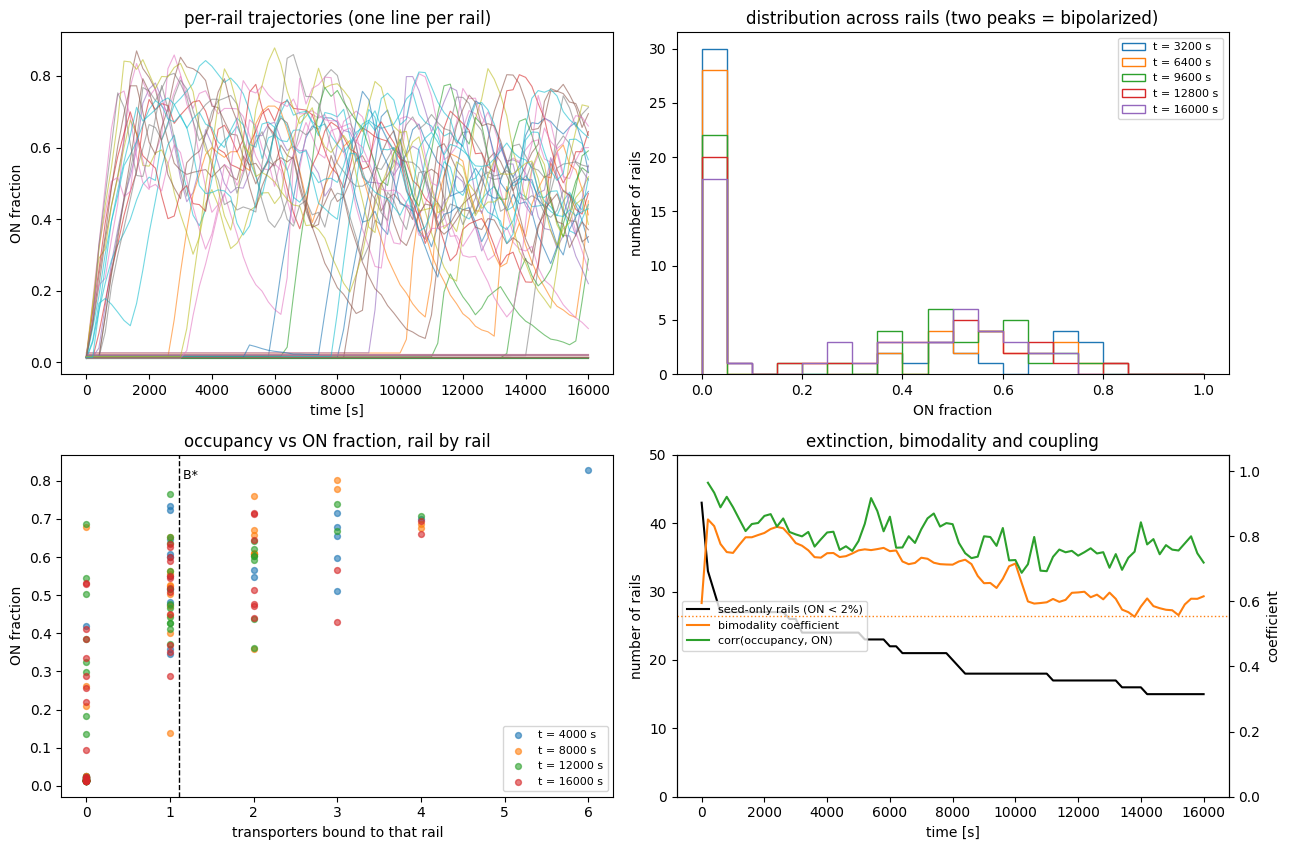


final state: 18 low / 9 intermediate / 23 high (low: ON < 5%, high: ON > 40%)
switching: low->high 31 times, high->low 0 times
seed-only rails 15/50, bimodality coefficient = 0.62 (>0.56 suggests two peaks), corr(occupancy, ON) = 0.72


In [ ]:
# ============================================================
#  Bipolarization analysis: do the rails split into two groups?
# ============================================================
bound_per_rail = np.stack([np.bincount(r[r >= 0], minlength=N_RAILS) for r in snaps["rail"]])

# Occupancy needed to hold one entire rail ON:  K_OFF * L_sites = (SPEED/SITE_SPACING) * P_WRITE * B
B_star = K_OFF * rails["nsites"].mean() / ((SPEED / SITE_SPACING) * P_WRITE)
print(f"B*      = {B_star:5.1f}  transporters required to sustain one fully ON rail")
print(f"supply  = {N_TRANSPORTER / N_RAILS:5.1f}  transporters available per rail on average")
print(f"N_ON_max= {N_TRANSPORTER / B_star:5.1f}  rails that can be held fully ON at once")


def sarle_bc(x):
    """Sarle's bimodality coefficient; > 5/9 = 0.556 suggests a bimodal distribution."""
    x = np.asarray(x, dtype=float)
    n, m, sd = len(x), x.mean(), x.std()
    if sd == 0:
        return np.nan
    g1 = ((x - m) ** 3).mean() / sd ** 3
    g2 = ((x - m) ** 4).mean() / sd ** 4 - 3.0
    return (g1 ** 2 + 1.0) / (g2 + 3.0 * (n - 1) ** 2 / ((n - 2) * (n - 3)))


DEAD = 0.02          # a rail below this ON fraction counts as "seed only"
LOW, HIGH = 0.05, 0.40   # thresholds for the low and high states
bc = np.array([sarle_bc(f) for f in frac])
n_dead = (frac < DEAD).sum(axis=1)
corr = np.array([np.corrcoef(bound_per_rail[k], frac[k])[0, 1]
                 if frac[k].std() > 0 and bound_per_rail[k].std() > 0 else np.nan
                 for k in range(len(t))])

fig, axs = plt.subplots(2, 2, figsize=(13, 8.6))

axs[0, 0].plot(t, frac, lw=0.8, alpha=0.6)
axs[0, 0].set_xlabel("time [s]"); axs[0, 0].set_ylabel("ON fraction")
axs[0, 0].set_title("per-rail trajectories (one line per rail)")

for k in np.linspace(0, len(t) - 1, 6).astype(int)[1:]:
    axs[0, 1].hist(frac[k], bins=np.linspace(0, 1, 21), histtype="step",
                   lw=1.5, label=f"t = {t[k]:.0f} s")
axs[0, 1].legend(fontsize=8); axs[0, 1].set_xlabel("ON fraction"); axs[0, 1].set_ylabel("number of rails")
axs[0, 1].set_title("distribution across rails (two peaks = bipolarized)")

kk = np.linspace(0, len(t) - 1, 5).astype(int)[1:]
for k in kk:
    axs[1, 0].scatter(bound_per_rail[k], frac[k], s=18, alpha=0.6, label=f"t = {t[k]:.0f} s")
axs[1, 0].axvline(B_star, color="k", ls="--", lw=1.0)
axs[1, 0].text(B_star, 0.96, " B*", fontsize=9, va="top",
               transform=axs[1, 0].get_xaxis_transform())
axs[1, 0].set_xlabel("transporters bound to that rail"); axs[1, 0].set_ylabel("ON fraction")
axs[1, 0].legend(fontsize=8); axs[1, 0].set_title("occupancy vs ON fraction, rail by rail")

axs[1, 1].plot(t, n_dead, color="k", label=f"seed-only rails (ON < {DEAD:.0%})")
axs[1, 1].set_xlabel("time [s]"); axs[1, 1].set_ylabel("number of rails")
axs[1, 1].set_ylim(0, N_RAILS)
ax2 = axs[1, 1].twinx()
ax2.plot(t, bc, color="tab:orange", label="bimodality coefficient")
ax2.plot(t, corr, color="tab:green", label="corr(occupancy, ON)")
ax2.axhline(5 / 9, color="tab:orange", ls=":", lw=1.0)
ax2.set_ylim(0, 1.05); ax2.set_ylabel("coefficient")
h1, l1 = axs[1, 1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axs[1, 1].legend(h1 + h2, l1 + l2, fontsize=8, loc="center left")
axs[1, 1].set_title("extinction, bimodality and coupling")

fig.tight_layout(); plt.show()

# count switching events between the low and high states
state = np.where(frac > HIGH, 1, np.where(frac < LOW, -1, 0))
up = dn = 0
for j in range(N_RAILS):
    seq = [v for v in state[:, j] if v != 0]
    up += sum(1 for a, b in zip(seq[:-1], seq[1:]) if a == -1 and b == 1)
    dn += sum(1 for a, b in zip(seq[:-1], seq[1:]) if a == 1 and b == -1)

n_low, n_high = (frac[-1] < LOW).sum(), (frac[-1] > HIGH).sum()
print(f"\nfinal state: {n_low} low / {N_RAILS - n_low - n_high} intermediate / {n_high} high "
      f"(low: ON < {LOW:.0%}, high: ON > {HIGH:.0%})")
print(f"switching: low->high {up} times, high->low {dn} times")
print(f"seed-only rails {n_dead[-1]}/{N_RAILS}, bimodality coefficient = {bc[-1]:.2f} "
      f"(>0.56 suggests two peaks), corr(occupancy, ON) = {corr[-1]:.2f}")

In [ ]:
# ============================================================
#  Parameter sweep: locate the regime that looks bistable
#  (set RUN_SWEEP = True to run it; 16 conditions take 1-2 minutes)
# ============================================================
RUN_SWEEP = False      #@param {type:"boolean"}
SWEEP_T = 8000.0       #@param {type:"number"}
# edit the SWEEP_NT / SWEEP_KOFF lists below to change the grid
SWEEP_NT = [20, 40, 60, 100]
SWEEP_KOFF = [0.0006, 0.0008, 0.0015, 0.0030]


def sweep_one(nt, koff, T=8000.0):
    """Run one condition with N_TRANSPORTER and K_OFF overridden; return per-rail ON fraction and occupancy."""
    override = dict(N_TRANSPORTER=nt, K_OFF=koff, T_TOTAL=T, SAMPLE_EVERY=T)
    saved = {k: globals()[k] for k in override}
    globals().update(override)
    try:
        r, sn, _body, _seeded = simulate(verbose=False)
    finally:
        globals().update(saved)
    f = np.add.reduceat(sn["on"][-1].astype(np.int32), r["offset"]) / r["nsites"]
    last = sn["rail"][-1]
    b = np.bincount(last[last >= 0], minlength=N_RAILS)
    return f, b


if RUN_SWEEP:
    DARK, LIT = 0.05, 0.40      # thresholds for the dark and lit states
    n_dark = np.zeros((len(SWEEP_KOFF), len(SWEEP_NT)))
    n_mid = np.zeros_like(n_dark)
    n_lit = np.zeros_like(n_dark)
    for a, koff in enumerate(SWEEP_KOFF):
        for b_, nt in enumerate(SWEEP_NT):
            f, occ_b = sweep_one(nt, koff, SWEEP_T)
            n_dark[a, b_] = ((f < DARK) & (occ_b == 0)).sum()
            n_mid[a, b_] = ((f >= DARK) & (f <= LIT)).sum()
            n_lit[a, b_] = (f > LIT).sum()
            print(f"  N_TRANSPORTER={nt:4d} K_OFF={koff:7.4f} -> "
                  f"dark {int(n_dark[a, b_]):2d} / intermediate {int(n_mid[a, b_]):2d} / lit {int(n_lit[a, b_]):2d}")

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    for ax, M, ttl in zip(axs, [n_dark, n_mid, n_lit],
                          ["dark rails (no transporter)", "intermediate rails", "lit rails"]):
        im = ax.imshow(M, origin="lower", cmap="viridis", vmin=0, vmax=N_RAILS, aspect="auto")
        ax.set_xticks(range(len(SWEEP_NT)), [str(v) for v in SWEEP_NT])
        ax.set_yticks(range(len(SWEEP_KOFF)), [f"{v:g}" for v in SWEEP_KOFF])
        ax.set_xlabel("N_TRANSPORTER"); ax.set_ylabel("K_OFF [1/s]"); ax.set_title(ttl)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                ax.text(j, i, int(M[i, j]), ha="center", va="center", color="w", fontsize=9)
        fig.colorbar(im, ax=ax)
    fig.suptitle("bistable-looking regime = many dark AND many lit, few intermediate", y=1.02)
    fig.tight_layout(); plt.show()
else:
    print("Set RUN_SWEEP = True to sweep N_TRANSPORTER x K_OFF (takes 1-2 minutes).")

Set RUN_SWEEP = True to sweep N_TRANSPORTER x K_OFF (takes 1-2 minutes).


## What the sweep showed

With the previous settings (300 transporters, `K_OFF` = 0.002) every rail received transporters and
no visual difference appeared. Sweeping `N_TRANSPORTER`, `K_OFF`, `P_WRITE`, `RUN_LENGTH` and the
seed placement showed that three things control the bipolarization.

### 1. Seed position (`SEED_AT_START`)
A transporter can only move along the polarity, so **sites upstream of the seed can never be
switched ON**. With the seed at a random position, the maximum reachable ON fraction of a rail is
set by where its seed happens to sit, and the rails spread uniformly between 0 and 1. That was the
real origin of the "20-30 intermediate rails" in the earlier version: geometric scatter, not
bistability. With the seed at the upstream end each rail is either almost fully ON or seed-only.

### 2. Transporter scarcity (`N_TRANSPORTER`)
The occupancy needed to hold one rail is `B* = K_OFF x L_sites / ((SPEED/SITE_SPACING) x P_WRITE)`.
Only when `N_TRANSPORTER / B*` is **smaller** than `N_RAILS` does competition produce winners and
losers. With 300 transporters `N_ON_max` was 87 rails against 50 rails present, so every rail could win.

### 3. Erasure rate (`K_OFF`)
Too large and everything dies; too small and everything lights up.

### Sweep results (50 rails, at t = 8000 s; dark = ON < 5 % and no transporter bound)

| `K_OFF` \ `N_TRANSPORTER` | 20 | 40 | 60 | 100 |
|---|---|---|---|---|
| 0.0006 | mostly dark | **20 dark / 26 lit** | 12 dark / 30 lit | nearly all lit |
| 0.0008 | mostly dark | **19 dark / 23 lit** | 6 dark / 34 lit | 6 dark / 36 lit |
| 0.0015 | dying out | 22 dark / 11 lit | 14 dark / 17 lit | 7 dark / 29 lit |
| 0.0030 | all dead | 34 dark / 0 lit | 26 dark / 0 lit | 12 dark / 3 lit |

The defaults are set to the sharpest separation found: `N_TRANSPORTER = 40`, `K_OFF = 0.0008`,
`P_WRITE = 1.0`, `RUN_LENGTH = 20`, `SEED_AT_START = True`. Under these settings the ON-fraction
histogram develops an empty valley between 0.1 and 0.2 and the bimodality coefficient reaches 0.62.
Set `RUN_SWEEP = True` in the cell above to reproduce the sweep yourself.

### Typical result at the default settings (16,000 s, about 8 s of compute)

* 18 low / 9 intermediate / 23 high rails, with 15 rails in the seed-only state
* 31 low-to-high switches and **zero high-to-low switches**: once ignited, a rail does not go back
* The snapshots separate cleanly into deep red rails carrying blue transporters and gray rails
  showing nothing but the orange seed

### Caveat: the coexistence is metastable
Extending `T_TOTAL` to 40,000 s reduces the dark rails from about 25 to about 13. The dark state has
a finite lifetime of tens of thousands of seconds and the system drifts slowly towards full ignition.
To keep the dark group for longer, lower `N_TRANSPORTER` to around 30.

### Other sweeps worth trying

| Goal | What to change |
|---|---|
| See high-to-low switching | raise `K_OFF` to 0.0015 (the high state becomes shallow enough to leave) |
| Isolate each mechanism | try `RUN_SCALES_WITH_ON = False` and `SEED_AT_START = False` separately; both destroy the separation |
| Light everything up | `N_TRANSPORTER` above 100 |
| Kill everything | `K_OFF` above 0.003 |

**On run length**: with `RUN_SCALES_WITH_ON = True`, `RUN_LENGTH` is the value at f = 1, so the
realized runs are shorter (mean 5.8 µm at the defaults; the run cell prints the measured value).
Two effects cause this: f never reaches 1, and runs are truncated at the rail end.